# MESA `basic.net` Network

The [MESA stellar evolution code](https://docs.mesastar.org) uses the [ `basic.net` network](https://docs.mesastar.org/en/26.4.1/net/nets.html) as a simple network for basic stellar evolution.  `basic.net` use 8 nuclei to approximate pp, CNO (but not hot-CNO), and He burning.  It also serves as the starting point for many other nets in MESA.

pynucastro can make a version of `basic.net` using {py:obj}`ApproximateRate <pynucastro.rates.approximate_rates.ApproximateRate>`, {py:obj}`BranchedRate <pynucastro.rates.branched_rate.BranchedRate>`, and {py:obj}`ModifiedRate <pynucastro.rates.modified_rate.ModifiedRate>`.

## Approximations

The approximations used in `basic.net` include:

* pp-chains:

  * $d$ is not evolved, so the sequences $p(p,e^+\nu)d(p,\gamma){}^{3}\mathrm{He}$ and
    it's electron capture equivalent are treated as a single rate.  We'll use `ModifiedRate` for this.
  * The pp-II and pp-III chains are also approximated, via the rate sequences:
    
    * ${}^4{\rm He}({}^3{\rm He},\gamma){}^7{\rm Be}(e^-,\nu){}^7{\rm Li}(p,\alpha){}^4{\rm He}$
    * ${}^4{\rm He}({}^3{\rm He},\gamma){}^7{\rm Be}(p,\gamma){}^8{\rm B}(,e^+\nu){}^8{\rm B}(,\alpha){}^4{\rm He}$

    We could treat these as separate rates, using a `BranchedRate` on ${}^7\mathrm{Be}$ (although currently
    `BranchedRate` assumes that the reactants are the same for the branched).  However, since these two
    branches have the same endpoint, we could just use a `ModifiedRate`.  The only reason to treat them
    separately is if we want to account for the different neutrino energy loss in the two branches.

    ```{note}
    Currently, pynucastro does not have a data source for these neutino energies, so they will not be
    accounted for.

  * The remaining rates, $^{3}{\rm He}(^{3}{\rm He},2p)^{4}{\rm He}$ and ${}^3{\rm He}(p,e^+\nu){}^4{\rm He}$
    are just regular ReacLib rates.

* CNO:

  * We will use the approximation from {doc}`branched-rates`.  This approximates the sequences:
 
    * ${}^{12}{\rm C}(p, \gamma){}^{13}{\rm N}(,e^+\nu){}^{13}{\rm C}(p,\gamma){}^{14}{\rm N}$
    * ${}^{14}{\rm N}(p, \gamma){}^{15}{\rm O}(,e^+\nu){}^{15}{\rm N}(p,\alpha){}^{12}{\rm C}$
    * ${}^{14}{\rm N}(p,\gamma){}^{15}{\rm O}(,e^+\nu){}^{15}{\rm N}(p,\gamma){}^{16}{\rm O}$
    * ${}^{16}{\rm O}(p,\gamma){}^{17}{\rm F}(,e^+\nu){}^{17}{\rm O}(p,\alpha){}^{14}{\rm N}$

    using `BranchedRate` or `ModifiedRate`.

  * This will not capture hot-CNO, since it does not consider the $\beta$-limiting from ${}^{14}\mathrm{O}$ and ${}^{15}\mathrm{O}$.  This is consistent with MESA's `basic.net`.
 
* He burning:

  * We will include triple alpha

  * For ${}^{12}\mathrm{C}(\alpha,\gamma){}^{16}\mathrm{O}$, we also include the alternate ${}^{12}{\rm C}(\alpha,p){}^{15}{\rm N}(p,\gamma){}^{16}{\rm O}$ using `ApproximateRate`

  * We include the "3/2-$\alpha$ capture onto ${}^{14}\mathrm{N}$ discussed in {doc}`modified-rates`.

  * Finally, we've add the $\alpha$-capture sequences:

    * $^{16}{\rm O}(\alpha,\gamma)^{20}{\rm Ne}$ + ${}^{16}{\rm O}(\alpha,p){}^{19}{\rm F}(p,\gamma)^{20}{\rm Ne}$
    * $^{20}{\rm Ne}(\alpha,\gamma)^{24}{\rm Mg}$ + $^{20}{\rm Ne}(\alpha,p){}^{23}{\rm Ne}(p,\gamma){}^{24}{\rm Mg}$

    using `ApproximateRate`

## Creating the pp rates

First we'll create the rates involved in pp-burning

In [1]:
import pynucastro as pyna

In [2]:
rl = pyna.ReacLibLibrary()

In [3]:
rpp, rpep = rl.get_rate_by_name("p(p,)d")

In [4]:
rpp, rpep

(p + p ⟶ H2 + e⁺ + 𝜈, p + p + e⁻ ⟶ H2 + 𝜈)

In [5]:
rppp_he3 = pyna.ModifiedRate(rpp,
                             new_products=[pyna.Nucleus("he3")],
                             stoichiometry={pyna.Nucleus("p"): 3},
                             description="p(p,e⁺ν)d(p,γ)He3",
                             rate_source=rpp.src)

In [6]:
rpepp_he3 = pyna.ModifiedRate(rpep,
                              new_products=[pyna.Nucleus("he3")],
                              stoichiometry={pyna.Nucleus("p"): 3},
                              description="p(pe⁻,ν)d(p,γ)He3",
                              rate_source=rpep.src)

In [7]:
rhe3he3 = rl.get_rate_by_name("he3(he3,pp)he4")

In [8]:
rhe3he4 = rl.get_rate_by_name("he4(he3,g)be7")
rhe3he4p_2he4 = pyna.ModifiedRate(rhe3he4,
                                  new_reactants=[pyna.Nucleus("he4"),
                                                 pyna.Nucleus("he3"), pyna.Nucleus("p")],
                                  new_products=[pyna.Nucleus("he4"),
                                                pyna.Nucleus("he4")],
                                  not_in_ydot_term=[pyna.Nucleus("p")],
                                  description="He4(He3,γ)Be7(e⁻,ν)Li7(p,α)He4")

In [9]:
lib_pp = pyna.Library(rates=[rppp_he3, rpepp_he3, rhe3he3, rhe3he4p_2he4])

## Creating the CNO rates

In [10]:
rc12pg = rl.get_rate_by_name("c12(p,g)n13")
rn14pg = rl.get_rate_by_name("n14(p,g)o15")
rn15pa = rl.get_rate_by_name("n15(p,a)c12")
rn15pg = rl.get_rate_by_name("n15(p,g)o16")
ro16pg = rl.get_rate_by_name("o16(p,g)f17")

In [11]:
rc12_2p_n14 = pyna.ModifiedRate(rc12pg,
                                new_products=[pyna.Nucleus("n14")],
                                stoichiometry={pyna.Nucleus("p"): 2},
                                description="C12(p,γ)N13(,e⁺ν)C13(p,γ)N14")

In [12]:
rn14_2p_c12 = pyna.BranchedRate(rn14pg,
                                primary_branch=rn15pa,
                                other_branch=rn15pg,
                                stoichiometry={pyna.Nucleus("p"): 2},
                                description="N14(p,γ)O15(,e⁺ν)N15(p,α)C12")

In [13]:
rn14_2p_o16 = pyna.BranchedRate(rn14pg,
                                primary_branch=rn15pg,
                                other_branch=rn15pa,
                                stoichiometry={pyna.Nucleus("p"): 2},
                                description="N14(p,γ)O15(,e⁺ν)N15(p,γ)O16")

In [14]:
ro16_2p_n14_a = pyna.ModifiedRate(ro16pg,
                                  new_products=[pyna.Nucleus("n14"),
                                                pyna.Nucleus("he4")],
                                  stoichiometry={pyna.Nucleus("p"): 2},
                                  description="O16(p,γ)F17(,e⁺ν)O17(p,α)N14")

In [15]:
lib_cno = pyna.Library(rates=[rc12_2p_n14, rn14_2p_c12, rn14_2p_o16, ro16_2p_n14_a])

## Creating the He-burning rates

In [16]:
r3a = rl.get_rate_by_name("a(aa,g)c12")

In [17]:
rc12ag, _ = pyna.rates.make_ap_pg_rates(rl, "c12", "o16", use_detailed_balance=True)

In [18]:
rn14ag = rl.get_rate_by_name("n14(a,g)f18")
rn14ag_lite = pyna.ModifiedRate(rn14ag,
                                new_products=["ne20"],
                                stoichiometry={pyna.Nucleus("he4"): 1.5})

In [19]:
ro16ag, _ = pyna.rates.make_ap_pg_rates(rl, "o16", "ne20", use_detailed_balance=True)
rne20ag, _ = pyna.rates.make_ap_pg_rates(rl, "ne20", "mg24", use_detailed_balance=True)

In [20]:
lib_he = pyna.Library(rates=[r3a, rc12ag, rn14ag_lite, ro16ag, rne20ag])

## Finally make the network

In [21]:
net = pyna.PythonNetwork(libraries=[lib_pp, lib_cno, lib_he],
                         allowed_duplicates=[(rppp_he3, rpepp_he3)])

In [22]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 8
  approximated-out nuclei: 3
  inert nuclei (included in carried): 0

  NSE compatible? False

  total number of rates: 38

  rates explicitly connecting nuclei: 13
  hidden rates: 25

  reaclib rates: 18
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 0
  approximate rates: 3
  derived rates: 9
  branched rates: 2
  modified rates: 6
  custom rates: 0


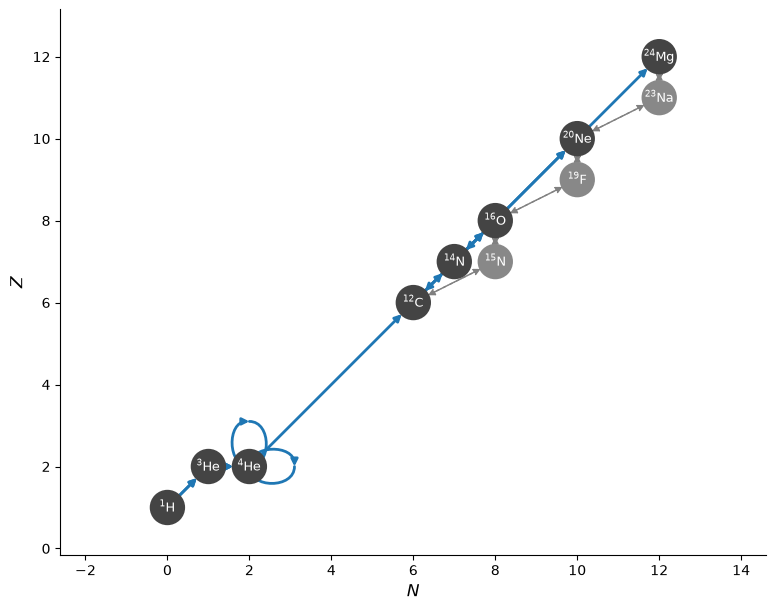

In [23]:
fig = net.plot(always_show_p=True, node_size=550, node_font_size="9")

## Integrating

We'll try integrating to see H burning followed by He burning.  We can't use too high of a temperature because we don't have the hot-CNO implemented ($\beta$-limiting of the rates).  

In [44]:
rho = 100
T = 1.e8
comp = pyna.Composition(net.unique_nuclei, init="solar")

In [48]:
tmax = 1.e23

In [49]:
sol = net.integrate_network(tmax, rho, T, comp)

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: N15 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


/home/zingale/development/pynucastro/pynucastro/networks/python_network.py:496: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


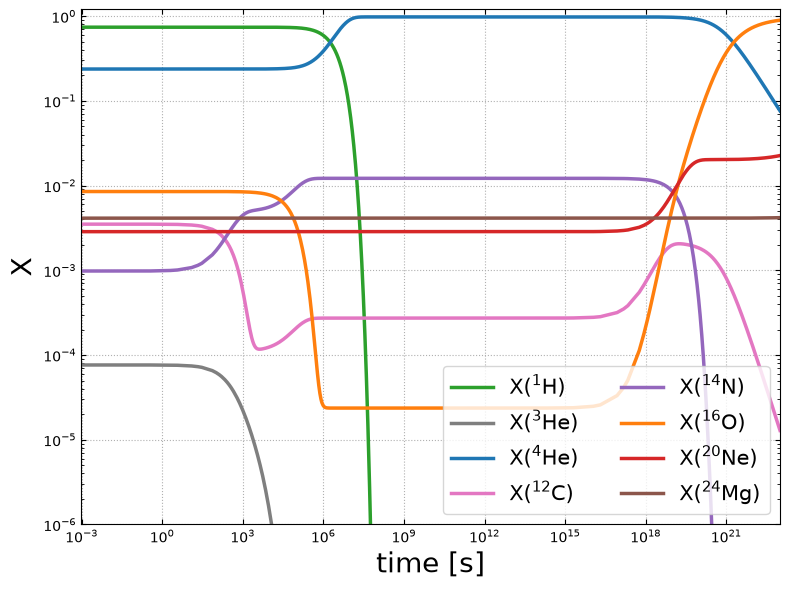

In [50]:
fig = sol.plot_evolution(ymin=1.e-6)